# 04 — CNN patch classifier

In this notebook, I train a small patch-based CNN to predict pore space in my cropped SEM/BSE images using the Weka masks as reference labels. I use this as a more flexible supervised model than the Random Forest, because the CNN can learn spatial patterns directly from image patches rather than relying only on handcrafted features.

My aim here is to test whether a CNN can predict pore masks and porosity more reliably than both Otsu thresholding and the Random Forest baseline. I then compare the predicted masks and porosity values against my Weka-derived masks and `porosity_weka` values.

**Workflow:** load inventory → prepare image-level train/validation/test splits → extract labelled image patches → train CNN → roll out predictions across full images → calculate segmentation and porosity metrics → save results → preview example outputs.

**Relevant course pages:**
- AI algorithms: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_AI_Algorithms.html
- Full-image rollout: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_rollout_3.html

**Notes**
- I keep the split at the image level so that patches from the same image do not leak across training, validation, and test data.
- I use the cropped images and corrected Weka masks from my inventory wherever available.
- I expect the CNN to improve on simpler methods because it can learn local pore texture and spatial structure directly from image patches.


In [6]:
from pathlib import Path
import os
from google.colab import drive

drive.mount('/content/drive')

REPO_ROOT = Path('/content/drive/MyDrive/GEOL0069-sem-segmentation-project')

if not REPO_ROOT.exists():
    !git clone https://github.com/courtneylorabrown/GEOL0069-sem-segmentation-project "{REPO_ROOT}"

%cd /content/drive/MyDrive/GEOL0069-sem-segmentation-project

DATA_DIR = REPO_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
CROPPED_DIR = DATA_DIR / 'cropped'
MASK_DIR = DATA_DIR / 'masks_weka'
PROB_DIR = DATA_DIR / 'probability_maps'
META_DIR = DATA_DIR / 'metadata'
RESULTS_DIR = REPO_ROOT / 'results'
MODELS_DIR = REPO_ROOT / 'models'
CNN_MASK_DIR = RESULTS_DIR / 'cnn_masks'
CNN_PROB_DIR = RESULTS_DIR / 'cnn_probability_maps'

for folder in [RAW_DIR, CROPPED_DIR, MASK_DIR, PROB_DIR, META_DIR, RESULTS_DIR, MODELS_DIR, CNN_MASK_DIR, CNN_PROB_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

INVENTORY_PATH = META_DIR / 'image_inventory.csv'

print("Inventory:", INVENTORY_PATH)
print("Cropped folder exists:", CROPPED_DIR.exists())
print("Mask folder exists:", MASK_DIR.exists())
print("Results folder exists:", RESULTS_DIR.exists())
print("Models folder exists:", MODELS_DIR.exists())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/GEOL0069-sem-segmentation-project
Inventory: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/data/metadata/image_inventory.csv
Cropped folder exists: True
Mask folder exists: True
Results folder exists: True
Models folder exists: True


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import (
    jaccard_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

PATCH = 33
HALF = PATCH // 2
BATCH_SIZE = 128
EPOCHS = 12


def read_gray(path):
    return np.array(Image.open(path).convert("L"))


def read_mask(path):
    arr = np.array(Image.open(path).convert("L"))
    return (arr < 128).astype(np.uint8)


def save_mask(mask, path):
    Image.fromarray((mask * 255).astype(np.uint8)).save(path)


def save_probability_map(prob, path):
    prob_uint8 = np.clip(prob * 255, 0, 255).astype(np.uint8)
    Image.fromarray(prob_uint8).save(path)


def align_mask_to_image(mask, image_shape):
    img_h, img_w = image_shape
    mask = mask[:img_h, :img_w]

    if mask.shape != image_shape:
        padded = np.zeros(image_shape, dtype=mask.dtype)
        padded[:mask.shape[0], :mask.shape[1]] = mask
        mask = padded

    return mask


def porosity_percent(mask):
    return float(mask.mean() * 100.0)


def segmentation_scores(gt, pred):
    return {
        "iou": jaccard_score(gt.ravel(), pred.ravel(), zero_division=0),
        "precision": precision_score(gt.ravel(), pred.ravel(), zero_division=0),
        "recall": recall_score(gt.ravel(), pred.ravel(), zero_division=0),
        "f1": f1_score(gt.ravel(), pred.ravel(), zero_division=0),
    }


def load_inventory(path=INVENTORY_PATH):
    df = pd.read_csv(path)

    for col in ["raw_file", "cropped_file", "weka_mask", "probability_map", "split", "notes"]:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str)

    if "porosity_weka" in df.columns:
        df["porosity_weka"] = pd.to_numeric(df["porosity_weka"], errors="coerce")

    return df


def assign_default_split(df):
    df = df.copy()

    if "split" not in df.columns:
        df["split"] = ""

    for mag, group in df.groupby("actual_magnification"):
        idx = group.sort_values("image_id").index.tolist()
        labels = []

        if len(idx) >= 1:
            labels.extend(["train"] * min(2, len(idx)))
        if len(idx) >= 3:
            labels.append("val")
        while len(labels) < len(idx):
            labels.append("test")

        for i, label in zip(idx, labels):
            if not str(df.loc[i, "split"]).strip():
                df.loc[i, "split"] = label

    return df


def sample_patch_centres(mask, n_per_class=3000, seed=42):
    rng = np.random.default_rng(seed)

    pos = np.argwhere(mask == 1)
    neg = np.argwhere(mask == 0)

    if len(pos) == 0 or len(neg) == 0:
        return np.empty((0, 2), dtype=int), np.empty((0,), dtype=np.uint8)

    n_pos = min(len(pos), n_per_class)
    n_neg = min(len(neg), n_per_class)

    pos_idx = rng.choice(len(pos), size=n_pos, replace=False)
    neg_idx = rng.choice(len(neg), size=n_neg, replace=False)

    coords = np.vstack([pos[pos_idx], neg[neg_idx]])
    labels = np.concatenate([np.ones(n_pos, dtype=np.uint8), np.zeros(n_neg, dtype=np.uint8)])

    shuffle_idx = rng.permutation(len(coords))
    return coords[shuffle_idx], labels[shuffle_idx]


def extract_patches_from_coords(image, coords):
    padded = np.pad(image, HALF, mode='reflect')
    patches = []

    for y, x in coords:
        patch = padded[y:y+PATCH, x:x+PATCH]
        patches.append(patch[..., None])

    X = np.stack(patches).astype('float32') / 255.0
    return X


def build_patch_dataset(image, mask, n_per_class=3000, seed=42):
    coords, y = sample_patch_centres(mask, n_per_class=n_per_class, seed=seed)
    if len(coords) == 0:
        return None, None
    X = extract_patches_from_coords(image, coords)
    return X, y.astype('float32')


def rollout_patch_model(model, image, batch_size=512):
    padded = np.pad(image, HALF, mode='reflect')
    h, w = image.shape

    coords = [(y, x) for y in range(h) for x in range(w)]
    probs = np.zeros(h * w, dtype=np.float32)

    for start in range(0, len(coords), batch_size):
        batch_coords = coords[start:start + batch_size]
        patches = []

        for y, x in batch_coords:
            patch = padded[y:y+PATCH, x:x+PATCH]
            patches.append(patch[..., None])

        X = np.stack(patches).astype('float32') / 255.0
        probs[start:start + len(batch_coords)] = model.predict(X, verbose=0).ravel()

    prob_map = probs.reshape(h, w)
    pred_mask = (prob_map >= 0.5).astype(np.uint8)

    return pred_mask, prob_map


def show_triplet(image, mask, pred, title=""):
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))

    ax[0].imshow(image, cmap='gray')
    ax[0].set_title(f"{title} image")
    ax[0].axis('off')

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Weka mask")
    ax[1].axis('off')

    ax[2].imshow(pred, cmap='gray')
    ax[2].set_title("CNN prediction")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()


In [8]:
df = assign_default_split(load_inventory())

display(df[[
    "image_id",
    "actual_magnification",
    "cropped_file",
    "weka_mask",
    "porosity_weka",
    "split"
]])

print("Number of rows:", len(df))

split_summary = (
    df.groupby(["actual_magnification", "split"])
      .size()
      .reset_index(name="n_images")
      .sort_values(["actual_magnification", "split"])
)

display(split_summary)


,image_id,actual_magnification,cropped_file,weka_mask,porosity_weka,split
0,13064_05_17A_400X-8-83,400,13064_05_17A_400X-8-83cropped.tif,13064_05_17A_400X-8-83mask.tif,1.000000,train
1,13074_00_18A_400X-9-10,400,13074_00_18A_400X-9-10cropped.tif,13074_00_18A_400X-9-10mask.tif,0.070000,train
2,13123_00_21A_400X-9-59,400,13123_00_21A_400X-9-59cropped.tif,13123_00_21A_400X-9-59mask.tif,2.268000,val
3,R2_10,400,R2_10cropped.tif,R2_10mask.tif,0.000477,test
4,13064_05_17B_1000X-8-83,1000,13064_05_17B_1000X-8-83cropped.tif,13064_05_17B_1000X-8-83mask.tif,1.987000,train
5,13087_50_19B_1000X-9-23,1000,13087_50_19B_1000X-9-23cropped.tif,13087_50_19B_1000X-9-23mask.tif,1.830000,train
6,13103_60_20B_1000X-9-39,1000,13103_60_20B_1000X-9-39cropped.tif,13103_60_20B_1000X-9-39mask.tif,0.445000,val
7,13123_00_21B_1000X-9-59,1000,13123_00_21B_1000X-9-59cropped.tif,13123_00_21B_1000X-9-59mask.tif,1.500000,test
8,13064_05_17C_2000X-8-83,2000,13064_05_17C_2000X-8-83cropped.tif,13064_05_17C_2000X-8-83mask.tif,2.078000,train
9,13087_50_19C_2000X-9-23,2000,13087_50_19C_2000X-9-23cropped.tif,13087_50_19C_2000X-9-23mask.tif,3.567000,train


Number of rows: 16


,actual_magnification,split,n_images
0,400,test,1
1,400,train,2
2,400,val,1
3,1000,test,1
4,1000,train,2
5,1000,val,1
6,2000,test,1
7,2000,train,2
8,2000,val,1
9,3000,test,1


In [9]:
X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
test_records = []

for _, row in df.iterrows():
    image_id = str(row["image_id"]).strip()
    split = str(row["split"]).strip().lower()

    cropped_name = str(row.get("cropped_file", "")).strip()
    raw_name = str(row.get("raw_file", "")).strip()
    mask_name = str(row.get("weka_mask", "")).strip()

    if cropped_name:
        image_path = CROPPED_DIR / cropped_name
    elif raw_name:
        image_path = RAW_DIR / raw_name
    else:
        print(f"Skipping {image_id}: no image file listed.")
        continue

    if not image_path.exists():
        print(f"Skipping {image_id}: image file not found -> {image_path.name}")
        continue

    if not mask_name:
        print(f"Skipping {image_id}: no mask listed.")
        continue

    mask_path = MASK_DIR / mask_name
    if not mask_path.exists():
        print(f"Skipping {image_id}: mask file not found -> {mask_name}")
        continue

    image = read_gray(image_path)
    mask = read_mask(mask_path)
    mask = align_mask_to_image(mask, image.shape)

    if split == "train":
        X, y = build_patch_dataset(image, mask, n_per_class=3000, seed=42)
        if X is not None:
            X_train_list.append(X)
            y_train_list.append(y)

    elif split == "val":
        X, y = build_patch_dataset(image, mask, n_per_class=1500, seed=42)
        if X is not None:
            X_val_list.append(X)
            y_val_list.append(y)

    else:
        test_records.append({
            "image_id": image_id,
            "image": image,
            "mask": mask,
            "porosity_weka": row.get("porosity_weka", np.nan),
            "actual_magnification": row.get("actual_magnification", np.nan),
        })

X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)

if len(X_val_list) > 0:
    X_val = np.concatenate(X_val_list)
    y_val = np.concatenate(y_val_list)
else:
    X_val = np.empty((0, PATCH, PATCH, 1), dtype='float32')
    y_val = np.empty((0,), dtype='float32')

print("Training patches:", X_train.shape, y_train.shape)
print("Validation patches:", X_val.shape, y_val.shape)
print("Number of test images:", len(test_records))
print("Training pore fraction:", y_train.mean())


Training patches: (45636, 33, 33, 1) (45636,)
Validation patches: (12000, 33, 33, 1) (12000,)
Number of test images: 4
Training pore fraction: 0.4740994


### Training the CNN

Here I train a small patch-based CNN. Each patch is labelled by the class of its centre pixel in the Weka mask, so the model learns to classify local image neighbourhoods as pore or non-pore.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 33, 33, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,409 (99.25 KB)

 Trainable params: 25,409 (99.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 52s 134ms/step - accuracy: 0.9110 - loss: 0.2143 - val_accuracy: 0.9397 - val_loss: 0.1551
Epoch 2/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 83s 136ms/step - accuracy: 0.9494 - loss: 0.1359 - val_accuracy: 0.9529 - val_loss: 0.1265
Epoch 3/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 50s 140ms/step - accuracy: 0.9619 - loss: 0.1082 - val_accuracy: 0.9657 - val_loss: 0.0980
Epoch 4/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 79s 132ms/step - accuracy: 0.9674 - loss: 0.0945 - val_accuracy: 0.9688 - val_loss: 0.0891
Epoch 5/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 83s 134ms/step - accuracy: 0.9699 - loss: 0.0887 - val_accuracy: 0.9705 - val_loss: 0.0872
Epoch 6/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.9719 - loss: 0.0851 - val_accuracy: 0.9727 - val_loss: 0.0824
Epoch 7/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 47s 132ms/step - accuracy: 0.9728 - loss: 0.0828 - val_accuracy: 0.9739 - val_loss: 0.0831
Epoch 8/12
357/357 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.9736 - loss: 0

,accuracy,loss,val_accuracy,val_loss
6,0.972785,0.082777,0.973917,0.083058
7,0.973595,0.079289,0.975833,0.076893
8,0.974735,0.078215,0.974250,0.079605
9,0.974976,0.075861,0.972583,0.085486
10,0.976181,0.074499,0.971917,0.083007


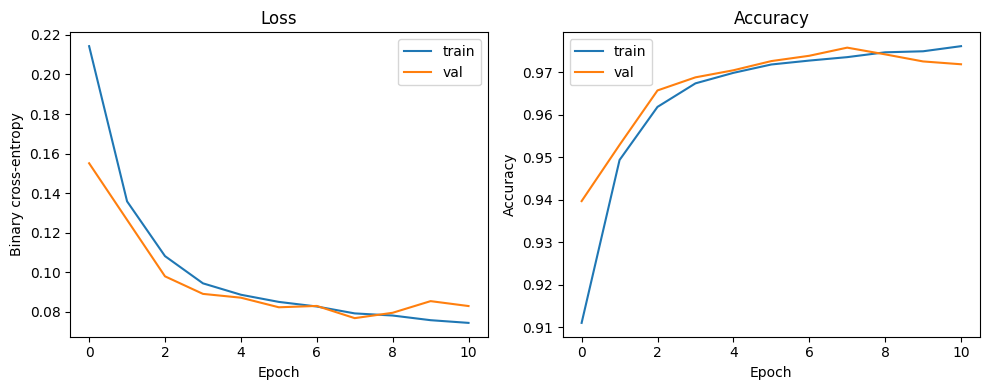

In [10]:
model = keras.Sequential([
    layers.Input(shape=(PATCH, PATCH, 1)),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.Conv2D(16, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

checkpoint_path = MODELS_DIR / 'cnn_patch_classifier.keras'

callbacks = [
    keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True),
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
]

fit_kwargs = dict(
    x=X_train,
    y=y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

if len(X_val) > 0:
    fit_kwargs["validation_data"] = (X_val, y_val)
else:
    fit_kwargs["validation_split"] = 0.1

history = model.fit(**fit_kwargs)

print("Saved model to:", checkpoint_path)

history_df = pd.DataFrame(history.history)
history_csv = RESULTS_DIR / "cnn_training_history.csv"
history_df.to_csv(history_csv, index=False)
print("Saved training history to:", history_csv)

display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Full-image rollout and test evaluation

After training on small labelled patches, I now apply the CNN across each full test image to generate a predicted pore mask and probability map. I then compare these against the Weka masks and porosity values.


,image_id,actual_magnification,weka_porosity,cnn_porosity,pred_mask_file,pred_probability_file,iou,precision,recall,f1,abs_error
0,R2_10,400,0.000477,0.000000,R2_10_cnn_mask.png,R2_10_cnn_probability.png,0.000000,0.000000,0.000000,0.000000,0.000477
1,13123_00_21B_1000X-9-59,1000,1.500000,5.625722,13123_00_21B_1000X-9-59_cnn_mask.png,13123_00_21B_1000X-9-59_cnn_probability.png,0.264907,0.265278,0.994743,0.418856,4.125722
2,B3_2,2000,0.913000,0.000000,B3_2_cnn_mask.png,B3_2_cnn_probability.png,0.000000,0.000000,0.000000,0.000000,0.913000
3,13162_65_24D_3000X-10-8,3000,3.408000,6.231470,13162_65_24D_3000X-10-8_cnn_mask.png,13162_65_24D_3000X-10-8_cnn_probability.png,0.464479,0.490613,0.897114,0.634327,2.823470


Saved test results to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/cnn_test_results.csv
Saved summary to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/cnn_summary_by_magnification.csv


,actual_magnification,n_images,mean_weka_porosity,mean_cnn_porosity,mean_abs_error,mean_iou,mean_f1
0,400,1,0.000477,0.000000,0.000477,0.000000,0.000000
1,1000,1,1.500000,5.625722,4.125722,0.264907,0.418856
2,2000,1,0.913000,0.000000,0.913000,0.000000,0.000000
3,3000,1,3.408000,6.231470,2.823470,0.464479,0.634327


              precision    recall  f1-score   support

           0      0.997     0.983     0.990   3847051
           1      0.383     0.760     0.510     53685

    accuracy                          0.980   3900736
   macro avg      0.690     0.872     0.750   3900736
weighted avg      0.988     0.980     0.983   3900736



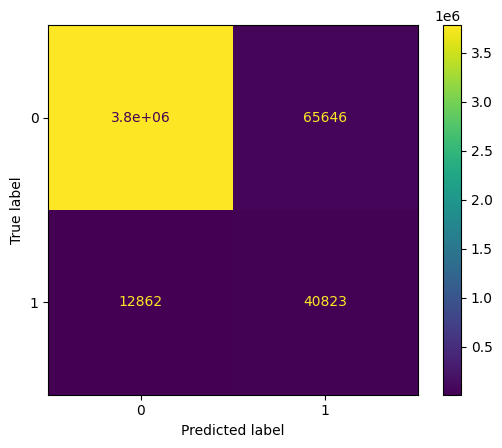

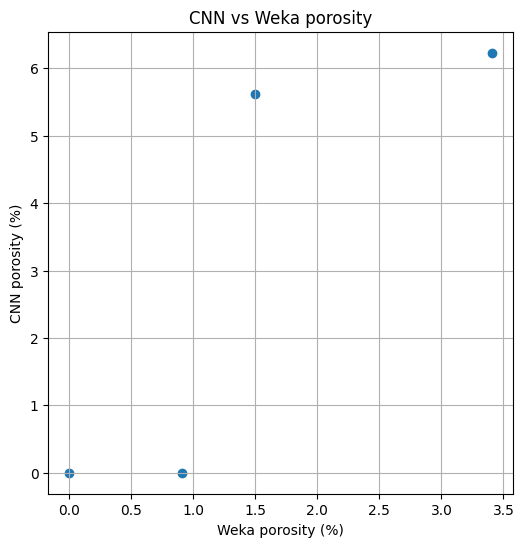

In [11]:
rows = []
y_true_all, y_pred_all = [], []

for item in test_records:
    image_id = item["image_id"]
    image = item["image"]
    mask = item["mask"]
    weka_por = item["porosity_weka"]
    magnification = item["actual_magnification"]

    pred, probs = rollout_patch_model(model, image, batch_size=512)

    mask_path = CNN_MASK_DIR / f"{image_id}_cnn_mask.png"
    prob_path = CNN_PROB_DIR / f"{image_id}_cnn_probability.png"

    save_mask(pred, mask_path)
    save_probability_map(probs, prob_path)

    y_true_all.append(mask.ravel())
    y_pred_all.append(pred.ravel())

    row = {
        "image_id": image_id,
        "actual_magnification": magnification,
        "weka_porosity": weka_por,
        "cnn_porosity": porosity_percent(pred),
        "pred_mask_file": mask_path.name,
        "pred_probability_file": prob_path.name,
    }
    row.update(segmentation_scores(mask, pred))
    rows.append(row)

cnn_test_results = pd.DataFrame(rows)

if not cnn_test_results.empty:
    cnn_test_results["abs_error"] = (cnn_test_results["cnn_porosity"] - cnn_test_results["weka_porosity"]).abs()
    display(cnn_test_results)

    test_csv = RESULTS_DIR / "cnn_test_results.csv"
    cnn_test_results.to_csv(test_csv, index=False)
    print("Saved test results to:", test_csv)

    summary = (
        cnn_test_results
        .groupby("actual_magnification", dropna=False)
        .agg(
            n_images=("image_id", "count"),
            mean_weka_porosity=("weka_porosity", "mean"),
            mean_cnn_porosity=("cnn_porosity", "mean"),
            mean_abs_error=("abs_error", "mean"),
            mean_iou=("iou", "mean"),
            mean_f1=("f1", "mean"),
        )
        .reset_index()
    )

    summary_csv = RESULTS_DIR / "cnn_summary_by_magnification.csv"
    summary.to_csv(summary_csv, index=False)
    print("Saved summary to:", summary_csv)
    display(summary)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    print(classification_report(y_true, y_pred, digits=3))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(cnn_test_results["weka_porosity"], cnn_test_results["cnn_porosity"])
    plt.xlabel("Weka porosity (%)")
    plt.ylabel("CNN porosity (%)")
    plt.title("CNN vs Weka porosity")
    plt.grid(True)
    plt.show()
else:
    print("No test results were generated.")


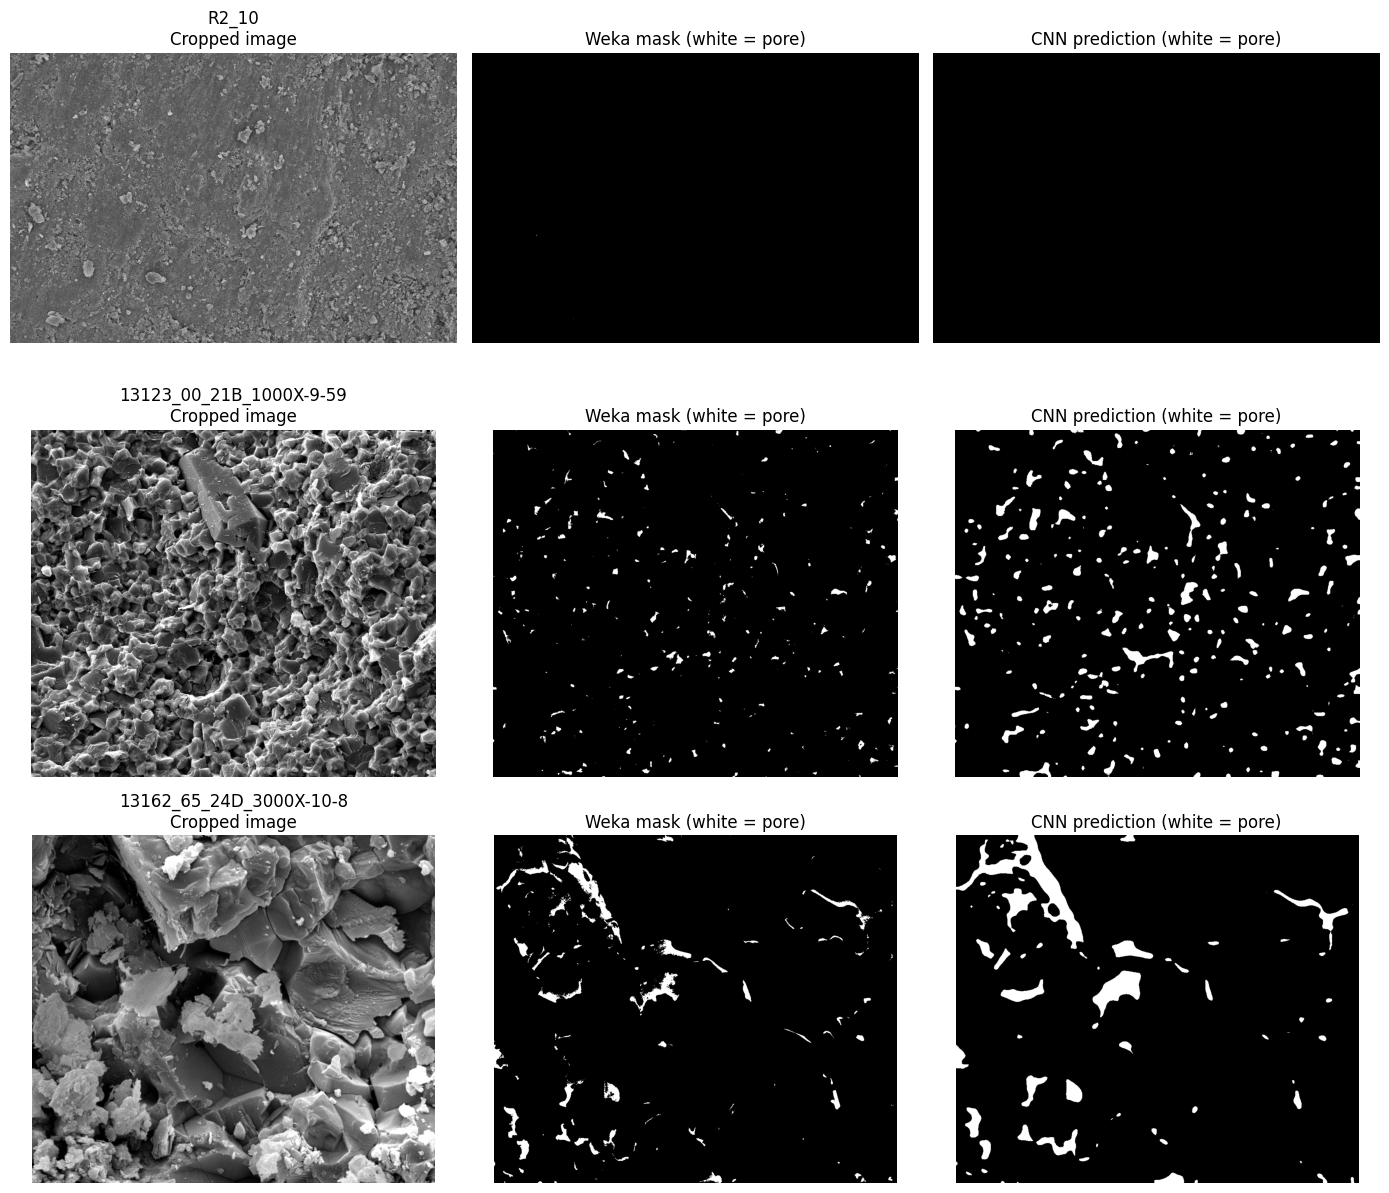

Selected images:
- R2_10
- 13123_00_21B_1000X-9-59
- 13162_65_24D_3000X-10-8


,image_id,actual_magnification,weka_porosity,cnn_porosity,iou,precision,recall,f1,abs_error
0,R2_10,400,0.000477,0.000000,0.000000,0.000000,0.000000,0.000000,0.000477
1,13123_00_21B_1000X-9-59,1000,1.500000,5.625722,0.264907,0.265278,0.994743,0.418856,4.125722
2,13162_65_24D_3000X-10-8,3000,3.408000,6.231470,0.464479,0.490613,0.897114,0.634327,2.823470


In [14]:
# Show 3 test examples: low, middle, and high porosity

def read_saved_pred_mask(path):
    arr = np.array(Image.open(path).convert("L"))
    return (arr > 0).astype(np.uint8)  # saved prediction: white = pore

if len(test_records) > 0 and not cnn_test_results.empty:
    view_df = cnn_test_results.copy()
    view_df["weka_porosity"] = pd.to_numeric(view_df["weka_porosity"], errors="coerce")
    view_df = view_df.dropna(subset=["weka_porosity"]).sort_values("weka_porosity").reset_index(drop=True)

    if len(view_df) >= 3:
        sample_ids = [
            view_df.iloc[0]["image_id"],                  # lowest porosity
            view_df.iloc[len(view_df) // 2]["image_id"],  # middle porosity
            view_df.iloc[-1]["image_id"],                 # highest porosity
        ]
    else:
        sample_ids = view_df["image_id"].tolist()

    fig, axes = plt.subplots(len(sample_ids), 3, figsize=(14, 4 * len(sample_ids)))

    if len(sample_ids) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, sample_id in enumerate(sample_ids):
        sample_item = next(item for item in test_records if item["image_id"] == sample_id)
        result_row = cnn_test_results[cnn_test_results["image_id"] == sample_id].iloc[0]

        image = sample_item["image"]
        mask = sample_item["mask"]

        pred_path = CNN_MASK_DIR / result_row["pred_mask_file"]
        if pred_path.exists():
            pred = read_saved_pred_mask(pred_path)
        else:
            pred = np.zeros_like(mask)

        axes[r, 0].imshow(image, cmap="gray")
        axes[r, 0].set_title(f"{sample_id}\nCropped image")
        axes[r, 0].axis("off")

        axes[r, 1].imshow(mask, cmap="gray")
        axes[r, 1].set_title("Weka mask (white = pore)")
        axes[r, 1].axis("off")

        axes[r, 2].imshow(pred, cmap="gray")
        axes[r, 2].set_title("CNN prediction (white = pore)")
        axes[r, 2].axis("off")

    plt.tight_layout()
    plt.show()

    print("Selected images:")
    for sample_id in sample_ids:
        print("-", sample_id)

    display(
        cnn_test_results.loc[
            cnn_test_results["image_id"].isin(sample_ids),
            [
                "image_id",
                "actual_magnification",
                "weka_porosity",
                "cnn_porosity",
                "iou",
                "precision",
                "recall",
                "f1",
                "abs_error",
            ],
        ]
        .sort_values("weka_porosity")
        .reset_index(drop=True)
    )

else:
    print("No test examples available to preview.")


## Conclusion

In this notebook, I trained a patch-based CNN to predict pore space from my cropped SEM/BSE images using the Weka masks as reference labels. The model learned some useful pore-related features and produced reasonable results on certain test images, particularly where visible pore space was clearer, but its performance remained inconsistent across the dataset.

The CNN struggled on very low-porosity images and often overpredicted porosity relative to the Weka masks, even when the spatial overlap was moderate. Overall, this shows that the CNN can capture some pore patterns, but on this small dataset it was not consistently reliable and did not clearly outperform the Random Forest baseline. It is therefore useful as a deep-learning comparison, while also indicating that more data or further tuning would be needed for a more robust CNN-based porosity predictor.
